In [59]:
import os
import random
import numpy as np
import mlflow
import torch
import glob 
import copy
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import pandas as pd
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score, f1_score, precision_score, recall_score,
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_auc_score, RocCurveDisplay
)


if torch.backends.mps.is_available():
    device = torch.device("mps")      # Mac GPU (Apple Silicon)
elif torch.cuda.is_available():
    device = torch.device("cuda")     # Nvidia GPU
else:
    device = torch.device("cpu")

# device = torch.device("cpu")  # Force CPU for testing time
random_seed = 42


mlflow.set_tracking_uri("http://127.0.0.1:5000")
mlflow.set_experiment("Running_or_not")
mlflow.enable_system_metrics_logging()


In [74]:
def input_target_split(dataframe):
    input_cols = []
    for c in dataframe.columns:
        if c.endswith("_x") or c.endswith("_y") or c.endswith("_z"):
            input_cols.append(c)

    input_data = dataframe[input_cols]
    target_data = dataframe[["running_video"]]  # Binary label: 1 frame per timestep
    return input_data, target_data


def split_data_by_video(datafolder, seq_length=30, stride=30,
                        train_ratio=0.7, val_ratio=0.15, random_seed=42):
    """
    Split by VIDEO FILE to prevent ANY data leakage between train/val/test.

    Returns:
        train_x, train_y, val_x, val_y, test_x, test_y
        X shape: (n_sequences, seq_length, 39)   -- all x/y/z coords
        y shape: (n_sequences, seq_length, 1)    -- binary running_video label
    """


    csv_files = glob.glob(os.path.join(datafolder, "*.csv"))
    print(f"Found {len(csv_files)} video files")

    random.seed(random_seed)
    random.shuffle(csv_files)

    n_files = len(csv_files)
    n_train = int(n_files * train_ratio)
    n_val = int(n_files * val_ratio)

    train_files = csv_files[:n_train]
    val_files   = csv_files[n_train:n_train + n_val]
    test_files  = csv_files[n_train + n_val:]

    frame_idx = 0
    for file_path in test_files:
        df = pd.read_csv(file_path)
        n_sequences = len(df) // seq_length
        n_frames    = n_sequences * seq_length
        start       = frame_idx
        end         = frame_idx + n_frames

        if start <= 1100 <= end or start <= 1600 <= end:
            print(f"Broken video candidate: {file_path}")
            print(f"  Frames {start} → {end}")

        frame_idx = end

    print(f"Train videos: {len(train_files)}, Val videos: {len(val_files)}, Test videos: {len(test_files)}")

    def extract_sequences(file_list):
        all_X, all_y = [], []
        for file_path in file_list:
            df = pd.read_csv(file_path)
            X_df, y_df = input_target_split(df)
            X_np = X_df.values.astype(np.float32)
            y_np = y_df.values.astype(np.float32)  # shape: (n_frames, 1)
            n_frames = len(df)
            for i in range(0, n_frames - seq_length + 1, stride):
                all_X.append(torch.tensor(X_np[i:i + seq_length]))
                all_y.append(torch.tensor(y_np[i:i + seq_length]))
        if not all_X:
            n_features = 39  # 13 joints x 3 coords
            return torch.empty(0, seq_length, n_features), torch.empty(0, seq_length, 1)
        return torch.stack(all_X), torch.stack(all_y)

    train_x, train_y = extract_sequences(train_files)
    val_x,   val_y   = extract_sequences(val_files)
    test_x,  test_y  = extract_sequences(test_files)

    print(f"\nTrain sequences: {len(train_x)}, Val: {len(val_x)}, Test: {len(test_x)}")
    print(f"X shape: {train_x.shape}, y shape: {train_y.shape}")

    return train_x, train_y, val_x, val_y, test_x, test_y



In [75]:
def mirror_sequences_tensor(X, Y):
    """
    Mirror sequences left-right.
    X: (n_sequences, seq_length, 39) -- x/y/z coords
    Y: (n_sequences, seq_length, 1)  -- binary label (unchanged by mirroring)
    """
    mirror_pairs = [
        (1, 3),   # shoulders
        (2, 4),   # elbows
        (5, 6),   # hands
        (7, 8),   # hips
        (9, 10),  # knees
        (11, 12), # feet
    ]

    X_mirrored = X.clone()

    for left, right in mirror_pairs:
        # x coords
        lx, rx = 3 * left, 3 * right
        X_mirrored[:, :, lx], X_mirrored[:, :, rx] = \
            -X_mirrored[:, :, rx].clone(), -X_mirrored[:, :, lx].clone()
        # y coords
        ly, ry = 3 * left + 1, 3 * right + 1
        X_mirrored[:, :, ly], X_mirrored[:, :, ry] = \
            X_mirrored[:, :, ry].clone(), X_mirrored[:, :, ly].clone()
        # z coords
        lz, rz = 3 * left + 2, 3 * right + 2
        X_mirrored[:, :, lz], X_mirrored[:, :, rz] = \
            X_mirrored[:, :, rz].clone(), X_mirrored[:, :, lz].clone()

    return X_mirrored, Y  # Label is unchanged by mirroring


def add_noise_to_sequences_tensor(X, Y, noise_std=0.002, prob=0.5, seed=None):
    """
    Add Gaussian noise to pose coordinates.
    X: (n_sequences, seq_length, 39)
    Y: (n_sequences, seq_length, 1)  -- binary label (unchanged)
    """
    if seed is not None:
        torch.manual_seed(seed)

    X_noisy = X.clone()
    mask = torch.rand(len(X)) < prob

    if mask.any():
        n_noisy = mask.sum().item()
        noise = torch.randn(n_noisy, X.shape[1], X.shape[2]) * noise_std
        X_noisy[mask] = X_noisy[mask] + noise

    return X_noisy, Y  # Label is unchanged by noise


In [76]:
class MovementClassifier(nn.Module):
    """
    Sequence-to-sequence binary classifier.
    Input:  (batch, seq_len, 39)  -- 13 joints x 3 coords
    Output: (batch, seq_len, 1)   -- logit per frame (use BCEWithLogitsLoss)
    """
    def __init__(self, hidden_layers: list, layer_type="LSTM", dropout=0.0):
        super().__init__()
        self.layer_type = layer_type

        input_size = 39  # 13 joints x 3 (x, y, z)
        rnn_class = nn.LSTM if layer_type == "LSTM" else nn.GRU

        self.rnns  = nn.ModuleList()
        self.drops = nn.ModuleList()

        sizes = [input_size] + hidden_layers
        for i in range(len(hidden_layers)):
            self.rnns.append(rnn_class(sizes[i], sizes[i + 1], batch_first=True))
            self.drops.append(nn.Dropout(dropout) if dropout > 0 else nn.Identity())

        self.fc_out = nn.Linear(hidden_layers[-1], 1)  # 1 logit per frame

    def forward(self, x):
        for rnn, drop in zip(self.rnns, self.drops):
            x, _ = rnn(x)
            x = drop(x)
        return self.fc_out(x)  # (batch, seq_len, 1)


In [77]:
class MovementClassifier_dense(nn.Module):
    """
    Sequence-to-sequence binary classifier.
    Input:  (batch, seq_len, 39)  -- 13 joints x 3 coords (x, y, z)
    Output: (batch, seq_len, 1)   -- logit per frame (use BCEWithLogitsLoss)
    """
    def __init__(self, hidden_size=160, dropout=0.0):
        super().__init__()

        self.fc_in  = nn.Linear(39, hidden_size)
        self.norm1  = nn.LayerNorm(hidden_size, eps=1e-5)
        self.act1   = nn.SiLU()
        self.drop1  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        self.fc_mid = nn.Linear(hidden_size, hidden_size)
        self.act2   = nn.SiLU()
        self.drop2  = nn.Dropout(dropout) if dropout > 0 else nn.Identity()

        self.fc_out = nn.Linear(hidden_size, 1)

    def forward(self, x):
        x = self.fc_in(x)    # (batch, seq_len, 39) -> (batch, seq_len, 160)
        x = self.norm1(x)
        x = self.act1(x)
        x = self.drop1(x)

        x = self.fc_mid(x)   # (batch, seq_len, 160) -> (batch, seq_len, 160)
        x = self.act2(x)
        x = self.drop2(x)

        return self.fc_out(x)  # (batch, seq_len, 1)

In [80]:
params = {
    "hidden_layers": [160, 160, 64],
    "layer_type": "LSTM",
    "dropout": 0.4,
    "learning_rate": 0.0005,
    "batch_size": 32,
    "epochs": 300,
    "seq_length": 30,
    "stride": 30,
    "weight_decay": 1e-6,
    "run_name": "kinetic_classifier_lstm",
    "patience": 100
}

datafolder = "../../MainProject/Assignment11/data/kinect_good_preprocessed_not_cut_start_stop"
#datafolder = "../../MainProject/Assignment11/data/mediapipe_not_cut_start_stop"
train_x, train_y, val_x, val_y, test_x, test_y = split_data_by_video(
    datafolder,
    seq_length=params["seq_length"],
    stride=params["stride"]
)


scaler = StandardScaler()

# Fit ONLY on training data
train_x_scaled = scaler.fit_transform(train_x.reshape(-1, train_x.shape[-1]))
train_x_scaled = train_x_scaled.reshape(train_x.shape)

# Only transform (no fit) on val and test
val_x_scaled = scaler.transform(val_x.reshape(-1, val_x.shape[-1]))
val_x_scaled = val_x_scaled.reshape(val_x.shape)

test_x_scaled = scaler.transform(test_x.reshape(-1, test_x.shape[-1]))
test_x_scaled = test_x_scaled.reshape(test_x.shape)

print(f"Train: {len(train_x)}, Val: {len(val_x)}, Test: {len(test_x)}")

train_x = torch.tensor(train_x_scaled, dtype=torch.float32).to(device)
train_y = torch.tensor(train_y, dtype=torch.float32).to(device)  # If train_y is numpy

val_x = torch.tensor(val_x_scaled, dtype=torch.float32).to(device)
val_y = torch.tensor(val_y, dtype=torch.float32).to(device)

test_x = torch.tensor(test_x_scaled, dtype=torch.float32).to(device)
test_y = torch.tensor(test_y, dtype=torch.float32).to(device)

pos = torch.sum(train_y == 1)
neg = torch.sum(train_y == 0)
pos_ratio = neg/pos
pos_weight = torch.tensor([pos_ratio], dtype=torch.float32).to(device)



model = MovementClassifier(
    hidden_layers=params["hidden_layers"],
    layer_type=params["layer_type"],
    dropout=params["dropout"]
).to(device)

""""
params = {
    "hidden_size": 160, 
    "dropout": 0.25,
    "learning_rate": 0.0005,
    "batch_size": 32,
    "epochs": 300,
    "seq_length": 30,
    "stride": 30,
    "weight_decay": 0,
    "patience": 20,
    "run_name": "teacher_arch_f1_loss",
}

model = MovementClassifier_dense(
    hidden_size=params["hidden_size"],
    dropout=params["dropout"]
).to(device)
"""

#loss_fn = nn.BCEWithLogitsLoss(pos_weight=pos_weight)  # Binary cross-entropy (includes sigmoid internally)
loss_fn = nn.BCEWithLogitsLoss()
optimizer = optim.Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])

Found 179 video files
Broken video candidate: ../../MainProject/Assignment11/data/kinect_good_preprocessed_not_cut_start_stop/A56_kinect.csv
  Frames 870 → 1110
Broken video candidate: ../../MainProject/Assignment11/data/kinect_good_preprocessed_not_cut_start_stop/B14_kinect.csv
  Frames 1350 → 1620
Train videos: 125, Val videos: 26, Test videos: 28

Train sequences: 801, Val: 185, Test: 182
X shape: torch.Size([801, 30, 39]), y shape: torch.Size([801, 30, 1])
Train: 801, Val: 185, Test: 182


/var/folders/h2/wsl1mbxn7q7_v_9543b88fx00000gn/T/ipykernel_68038/4232957442.py:40: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  train_y = torch.tensor(train_y, dtype=torch.float32).to(device)  # If train_y is numpy
/var/folders/h2/wsl1mbxn7q7_v_9543b88fx00000gn/T/ipykernel_68038/4232957442.py:43: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  val_y = torch.tensor(val_y, dtype=torch.float32).to(device)
/var/folders/h2/wsl1mbxn7q7_v_9543b88fx00000gn/T/ipykernel_68038/4232957442.py:46: UserWarning: To copy construct from a tensor, it is recommended to use sourceTensor.detach().clone() or sourceTensor.detach().clone().requires_grad_(True), rather than torch.tensor(sourceTensor).
  test_y = t

2026/04/28 22:25:46 INFO mlflow.system_metrics.system_metrics_monitor: Skip logging GPU metrics. Set logger level to DEBUG for more details.
2026/04/28 22:25:46 INFO mlflow.system_metrics.system_metrics_monitor: Started monitoring system metrics.


  → New best val F1: 0.8951 (epoch 1)
  → New best val F1: 0.9177 (epoch 3)
  → New best val F1: 0.9208 (epoch 4)
  → New best val F1: 0.9214 (epoch 5)
  → New best val F1: 0.9224 (epoch 9)
Epoch 10/300 | train_loss: 0.1720  train_f1: 0.9466 | val_loss: 0.2644  val_f1: 0.9270  val_acc: 0.9014
  → New best val F1: 0.9270 (epoch 10)
  → New best val F1: 0.9297 (epoch 16)
Epoch 20/300 | train_loss: 0.1445  train_f1: 0.9503 | val_loss: 0.2562  val_f1: 0.9133  val_acc: 0.8877
  → New best val F1: 0.9339 (epoch 24)
Epoch 30/300 | train_loss: 0.1222  train_f1: 0.9565 | val_loss: 0.2563  val_f1: 0.9342  val_acc: 0.9106
  → New best val F1: 0.9342 (epoch 30)
  → New best val F1: 0.9358 (epoch 37)
Epoch 40/300 | train_loss: 0.1158  train_f1: 0.9614 | val_loss: 0.2519  val_f1: 0.9261  val_acc: 0.9013
  → New best val F1: 0.9387 (epoch 41)
Epoch 50/300 | train_loss: 0.1214  train_f1: 0.9616 | val_loss: 0.2758  val_f1: 0.9229  val_acc: 0.8971
Epoch 60/300 | train_loss: 0.1013  train_f1: 0.9656 | va

2026/04/28 22:26:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.


Epoch 140/300 | train_loss: 0.0612  train_f1: 0.9797 | val_loss: 0.4102  val_f1: 0.9096  val_acc: 0.8822
Early stopping at epoch 141 — best val F1: 0.9387
Restored best model (val F1: 0.9387)


2026/04/28 22:26:10 WARNING mlflow.pytorch: Saving pytorch model by Pickle or CloudPickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is to set `serialization_format` to 'pt2' to save the PyTorch model using the safe graph model format.



✅ Test Results:
              precision    recall  f1-score   support

Not movement       0.86      0.86      0.86      2280
    Movement       0.90      0.90      0.90      3180

    accuracy                           0.88      5460
   macro avg       0.88      0.88      0.88      5460
weighted avg       0.88      0.88      0.88      5460



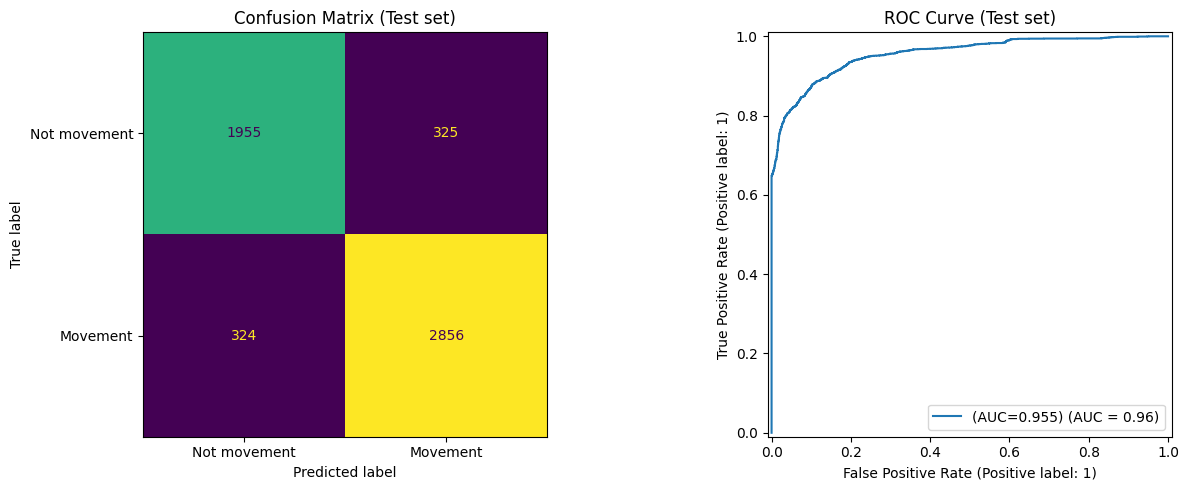

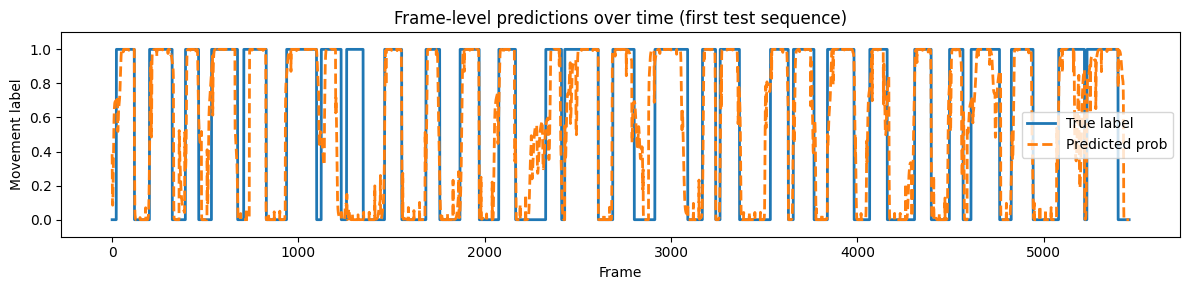

2026/04/28 22:26:12 INFO mlflow.system_metrics.system_metrics_monitor: Stopping system metrics monitoring...
2026/04/28 22:26:13 INFO mlflow.system_metrics.system_metrics_monitor: Successfully terminated system metrics monitoring!



AUC: 0.9552  |  F1: 0.8980  |  Accuracy: 0.8811
🏃 View run kinetic_classifier_lstm at: http://127.0.0.1:5000/#/experiments/4/runs/eb291e9e3fee4c8c89e2d838e286b61d
🧪 View experiment at: http://127.0.0.1:5000/#/experiments/4


In [81]:
def compute_classification_metrics(logits, targets):
    """Convert logits -> binary preds and compute accuracy, F1, precision, recall."""
    probs  = torch.sigmoid(logits).cpu().numpy().flatten()
    preds  = (probs > 0.5).astype(int)
    labels = targets.cpu().numpy().flatten().astype(int)
    return {
        "accuracy":  accuracy_score(labels, preds),
        "f1":        f1_score(labels, preds, zero_division=0),
        "precision": precision_score(labels, preds, zero_division=0),
        "recall":    recall_score(labels, preds, zero_division=0),
        "probs":     probs,
        "preds":     preds,
        "labels":    labels,
    }


with mlflow.start_run(run_name=params["run_name"]) as run:
    mlflow.log_params(params)

    train_dataset = TensorDataset(train_x, train_y)
    val_dataset   = TensorDataset(val_x,   val_y)
    test_dataset  = TensorDataset(test_x,  test_y)

    train_loader = DataLoader(train_dataset, batch_size=params["batch_size"], shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=params["batch_size"], shuffle=False)
    test_loader  = DataLoader(test_dataset,  batch_size=params["batch_size"], shuffle=False)

    best_val_f1       = -1.0
    best_model_state  = None
    epochs_no_improve = 0

    for epoch in range(params["epochs"]):

        # ── Training ─────────────────────────────────────────────────────────
        model.train()
        train_losses = []
        all_train_logits, all_train_labels = [], []

        for batch_x, batch_y in train_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)

            optimizer.zero_grad()
            logits = model(batch_x)
            loss   = loss_fn(logits, batch_y)
            loss.backward()
            optimizer.step()
            train_losses.append(loss.item())
            all_train_logits.append(logits.detach())
            all_train_labels.append(batch_y)

        avg_train_loss   = np.mean(train_losses)
        train_logits_cat = torch.cat(all_train_logits)
        train_labels_cat = torch.cat(all_train_labels)
        train_m          = compute_classification_metrics(train_logits_cat, train_labels_cat)

        # ── Validation ───────────────────────────────────────────────────────
        model.eval()
        val_losses = []
        all_val_logits, all_val_labels = [], []

        with torch.no_grad():
            for batch_x, batch_y in val_loader:
                batch_x = batch_x.to(device)
                batch_y = batch_y.to(device)
                logits  = model(batch_x)
                val_losses.append(loss_fn(logits, batch_y).item())
                all_val_logits.append(logits)
                all_val_labels.append(batch_y)

        avg_val_loss   = np.mean(val_losses)
        val_logits_cat = torch.cat(all_val_logits)
        val_labels_cat = torch.cat(all_val_labels)
        val_m          = compute_classification_metrics(val_logits_cat, val_labels_cat)

        mlflow.log_metrics({
            "train_loss":      avg_train_loss,
            "train_accuracy":  train_m["accuracy"],
            "train_f1":        train_m["f1"],
            "train_precision": train_m["precision"],
            "train_recall":    train_m["recall"],
            "val_loss":        avg_val_loss,
            "val_accuracy":    val_m["accuracy"],
            "val_f1":          val_m["f1"],
            "val_precision":   val_m["precision"],
            "val_recall":      val_m["recall"],
        }, step=epoch)

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1}/{params['epochs']} "
                  f"| train_loss: {avg_train_loss:.4f}  train_f1: {train_m['f1']:.4f} "
                  f"| val_loss: {avg_val_loss:.4f}  val_f1: {val_m['f1']:.4f}  "
                  f"val_acc: {val_m['accuracy']:.4f}")

        # ── Early stopping on val F1 ──────────────────────────────────────────
        if params.get("patience"):
            if val_m["f1"] > best_val_f1:
                best_val_f1      = val_m["f1"]
                best_model_state = copy.deepcopy(model.state_dict())
                epochs_no_improve = 0
                print(f"  → New best val F1: {best_val_f1:.4f} (epoch {epoch+1})")
            else:
                epochs_no_improve += 1
            if epochs_no_improve >= params["patience"]:
                print(f"Early stopping at epoch {epoch+1} — best val F1: {best_val_f1:.4f}")
                break

    # ── Restore best model before test eval ──────────────────────────────────
    if best_model_state is not None:
        model.load_state_dict(best_model_state)
        print(f"Restored best model (val F1: {best_val_f1:.4f})")

    # ── Test evaluation ───────────────────────────────────────────────────────
    model.eval()
    test_losses = []
    all_test_logits, all_test_labels = [], []

    with torch.no_grad():
        for batch_x, batch_y in test_loader:
            batch_x = batch_x.to(device)
            batch_y = batch_y.to(device)
            logits  = model(batch_x)
            test_losses.append(loss_fn(logits, batch_y).item())
            all_test_logits.append(logits)
            all_test_labels.append(batch_y)

    avg_test_loss   = np.mean(test_losses)
    test_logits_cat = torch.cat(all_test_logits)
    test_labels_cat = torch.cat(all_test_labels)
    test_m          = compute_classification_metrics(test_logits_cat, test_labels_cat)

    test_auc = roc_auc_score(test_m["labels"], test_m["probs"])

    mlflow.log_metrics({
        "test_loss":      avg_test_loss,
        "test_accuracy":  test_m["accuracy"],
        "test_f1":        test_m["f1"],
        "test_precision": test_m["precision"],
        "test_recall":    test_m["recall"],
        "test_auc":       test_auc,
    })

    mlflow.pytorch.log_model(model, artifact_path=f"best_model_{params['run_name']}")

    print(f"\n✅ Test Results:")
    print(classification_report(test_m["labels"], test_m["preds"],
                                target_names=["Not movement", "Movement"]))

    # ── Confusion matrix + ROC curve ─────────────────────────────────────────
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))

    cm = confusion_matrix(test_m["labels"], test_m["preds"])
    ConfusionMatrixDisplay(cm, display_labels=["Not movement", "Movement"]).plot(
        ax=axes[0], colorbar=False
    )
    axes[0].set_title("Confusion Matrix (Test set)")

    RocCurveDisplay.from_predictions(
        test_m["labels"], test_m["probs"],
        name=f"(AUC={test_auc:.3f})",
        ax=axes[1]
    )
    axes[1].set_title("ROC Curve (Test set)")

    plt.tight_layout()
    plt.savefig("test_evaluation.png", dpi=150)
    mlflow.log_artifact("test_evaluation.png")
    plt.show()

    # ── Temporal prediction plot ──────────────────────────────────────────────
    n_frames_to_plot = params["seq_length"] * 200  # ~1 full video
    first_seq_true  = test_m["labels"][:n_frames_to_plot]
    first_seq_probs = test_m["probs"][:n_frames_to_plot]

    fig2, ax = plt.subplots(figsize=(12, 3))
    ax.plot(first_seq_true,  label="True label",      linewidth=2)
    ax.plot(first_seq_probs, label="Predicted prob",  linewidth=2, linestyle="--")
    ax.set_xlabel("Frame")
    ax.set_ylabel("Movement label")
    ax.set_title("Frame-level predictions over time (first test sequence)")
    ax.legend()
    ax.set_ylim(-0.1, 1.1)
    plt.tight_layout()
    plt.savefig("temporal_predictions.png", dpi=150)
    mlflow.log_artifact("temporal_predictions.png")
    plt.show()

    print(f"\nAUC: {test_auc:.4f}  |  F1: {test_m['f1']:.4f}  |  Accuracy: {test_m['accuracy']:.4f}")

In [85]:
x = [0.9574, 0.9629, 0.9428, 0.9282, 0.9703, 0.9432, 0.9576, 0.9521, 0.9244, 0.9415]

print(np.std(x, ddof=1))

0.014749553665563356
